<a href="https://colab.research.google.com/github/saidanirafeek2011/Assignment-3-Data-Visualization.ipynb/blob/main/ModuleEnd__2nd_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
import os

print(os.getcwd())

/content


In [19]:
df = pd.read_csv('Online Retail.csv', encoding='latin1')
display(df.head())

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [11]:

df.tail()

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
25015,538351,22328,ROUND SNACK BOXES SET OF 4 FRUITS,1.0,12/10/2010 15:17,6.77,NaN,United Kingdom
25016,538351,22355,CHARLOTTE BAG SUKI DESIGN,267.0,12/10/2010 15:17,2.51,NaN,United Kingdom
25017,538351,22356,CHARLOTTE BAG PINK POLKADOT,35.0,12/10/2010 15:17,2.51,NaN,United Kingdom
25018,538351,22367,CHILDRENS APRON SPACEBOY DESIGN,9.0,12/10/2010 15:17,5.06,NaN,United Kingdom
25019,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:


df.shape

(25020, 8)

In [13]:


df.columns

Index(['ï»¿InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [20]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format='%m/%d/%Y %H:%M'
)
df['InvoiceDate']

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00
...,...
541904,2011-12-09 12:50:00
541905,2011-12-09 12:50:00
541906,2011-12-09 12:50:00
541907,2011-12-09 12:50:00


In [21]:
# Task 2 – Data Cleaning
print(df.isnull().sum())

ï»¿InvoiceNo         0
StockCode            0
Description       1454
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID      135080
Country              0
dtype: int64


In [22]:

#1. ● Handle missing values (remove null CustomerID)
df = df.dropna(subset=['CustomerID'])

In [23]:

# 2.Remove duplicates
df = df.drop_duplicates()

In [24]:

# ● Fix invalid values (negative quantity, invalid price)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Resets index
df = df.reset_index(drop=True)

In [25]:

# Check dataset
print(df.shape)
print(df.isnull().sum())

(392692, 8)
ï»¿InvoiceNo    0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
dtype: int64


In [26]:

# Task 3) 1. Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['TotalPrice']

,TotalPrice
0,15.30
1,20.34
2,22.00
3,20.34
4,20.34
...,...
392687,10.20
392688,12.60
392689,16.60
392690,16.60


In [27]:

# 2. Extract Time Features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayName'] = df['InvoiceDate'].dt.day_name()
print(df['Year'],df['Month'],df['Day'],df['Hour'],df['DayName'])

0         2010
1         2010
2         2010
3         2010
4         2010
          ... 
392687    2011
392688    2011
392689    2011
392690    2011
392691    2011
Name: Year, Length: 392692, dtype: int32 0         12
1         12
2         12
3         12
4         12
          ..
392687    12
392688    12
392689    12
392690    12
392691    12
Name: Month, Length: 392692, dtype: int32 0         1
1         1
2         1
3         1
4         1
         ..
392687    9
392688    9
392689    9
392690    9
392691    9
Name: Day, Length: 392692, dtype: int32 0          8
1          8
2          8
3          8
4          8
          ..
392687    12
392688    12
392689    12
392690    12
392691    12
Name: Hour, Length: 392692, dtype: int32 0         Wednesday
1         Wednesday
2         Wednesday
3         Wednesday
4         Wednesday
            ...    
392687       Friday
392688       Friday
392689       Friday
392690       Friday
392691       Friday
Name: DayName, Length: 392692, dt

In [28]:

# ● Create categories (Customer Segment, Order Size, Day Type)
df['CustomerSegment'] = 'High'
df.loc[df['TotalPrice'] < 20, 'CustomerSegment'] = 'Low'

# Order Size
df['OrderSize'] = 'Large'
df.loc[df['Quantity'] < 10, 'OrderSize'] = 'Small'

# Day Type
df['Day Type'] = 'Weekday'

df.loc[df['InvoiceDate'].dt.dayofweek >= 5, 'Day Type'] = 'Weekend'

print(df.head())

  ï»¿InvoiceNo StockCode                          Description  Quantity  \
0       536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1       536365     71053                  WHITE METAL LANTERN         6   
2       536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3       536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4       536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   

   Year  Month  Day  Hour    DayName CustomerSegment OrderSize Day Type  
0  2010     12    

In [29]:

# Task 4 – Data Exploration
# ● Use describe() and dataset overview
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Year,Month,Day,Hour
count,392692.000000,392692,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500,2010.934631,7.601871,15.044656,12.721532
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,6.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000,2011.000000,5.000000,7.000000,11.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000,2011.000000,8.000000,15.000000,13.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000,2011.000000,11.000000,22.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,180.492832,NaN,22.241836,1713.539549,311.099224,0.247177,3.415015,8.652532,2.276661


In [30]:
#datasetOverview (Already printed shape,tail,columns,missing values)
print("\nData Types:")
print(df.dtypes)
print("\nUnique Values:")
print(df.nunique())


Data Types:
ï»¿InvoiceNo               object
StockCode                  object
Description                object
Quantity                    int64
InvoiceDate        datetime64[ns]
UnitPrice                 float64
CustomerID                float64
Country                    object
TotalPrice                float64
Year                        int32
Month                       int32
Day                         int32
Hour                        int32
DayName                    object
CustomerSegment            object
OrderSize                  object
Day Type                   object
dtype: object

Unique Values:
ï»¿InvoiceNo       18532
StockCode           3665
Description         3877
Quantity             301
InvoiceDate        17282
UnitPrice            440
CustomerID          4338
Country               37
TotalPrice          2939
Year                   2
Month                 12
Day                   31
Hour                  15
DayName                6
CustomerSegment        2
Orde

In [31]:
# Analyze categories (value_counts()
print(df['CustomerSegment'].value_counts())
print(df['OrderSize'].value_counts())
print(df['Day Type'].value_counts())

CustomerSegment
Low     306407
High     86285
Name: count, dtype: int64
OrderSize
Small    245557
Large    147135
Name: count, dtype: int64
Day Type
Weekday    331480
Weekend     61212
Name: count, dtype: int64


In [32]:

#Analyze categories unique())
print(df['CustomerSegment'].unique())
print(df['OrderSize'].unique())
print(df['Day Type'].unique())

['Low' 'High']
['Small' 'Large']
['Weekday' 'Weekend']


In [33]:
# Perform groupby() (country, month, product)
# GROUP BY COUNTRY
country_group = df.groupby('Country')[['Quantity', 'TotalPrice']].sum()

print("Group By Country")
print(country_group)

Group By Country
                      Quantity   TotalPrice
Country                                    
Australia                83891   138453.810
Austria                   4881    10198.680
Bahrain                    260      548.400
Belgium                  23237    41196.340
Brazil                     356     1143.600
Canada                    2763     3666.380
Channel Islands           9485    20440.540
Cyprus                    6340    13502.850
Czech Republic             671      826.740
Denmark                   8235    18955.340
EIRE                    140133   265262.460
European Community         499     1300.250
Finland                  10704    22546.080
France                  111428   208934.310
Germany                 119154   228678.400
Greece                    1557     4760.520
Iceland                   2458     4310.000
Israel                    4043     7215.840
Italy                     8112    17483.240
Japan                    26016    37416.370
Lebanon        

In [34]:
# GROUP BY MONTH
month_group = df.groupby('Month')[['Quantity', 'TotalPrice']].sum()

print("Group By Month")
print(month_group)

Group By Month
       Quantity   TotalPrice
Month                       
1        348473   568101.310
2        265027   446084.920
3        347582   594081.760
4        291366   468374.331
5        372864   677355.150
6        363014   660046.050
7        367360   598962.901
8        397373   644051.040
9        543652   950690.202
10       591543  1035642.450
11       665923  1156205.610
12       597825  1087613.170


In [35]:
# GROUP BY PRODUCT (Description column)
product_group = df.groupby('Description')[['Quantity', 'TotalPrice']].sum()

print("Group By Product")
print(product_group)

Group By Product
                                  Quantity  TotalPrice
Description                                           
 4 PURPLE FLOCK DINNER CANDLES         138      265.66
 50'S CHRISTMAS GIFT BAG LARGE        1885     2272.25
 DOLLY GIRL BEAKER                    2394     2754.50
 I LOVE LONDON MINI BACKPACK           359     1449.85
 I LOVE LONDON MINI RUCKSACK             1        4.15
...                                    ...         ...
ZINC T-LIGHT HOLDER STARS SMALL       4894     3879.98
ZINC TOP  2 DOOR WOODEN SHELF           10      169.50
ZINC WILLIE WINKIE  CANDLE STICK      2606     2176.10
ZINC WIRE KITCHEN ORGANISER             25      156.80
ZINC WIRE SWEETHEART LETTER TRAY        80      253.24

[3877 rows x 2 columns]


In [36]:
# Task 5. Aggregate data using groupby()

# Total sales by customer
customer_sales = df.groupby('CustomerID')['TotalPrice'].sum()

print("************Customer Sales************")
print(customer_sales)

************Customer Sales************
CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2045.53
18287.0     1837.28
Name: TotalPrice, Length: 4338, dtype: float64


In [37]:

# Total sales by country
country_sales = df.groupby('Country')['TotalPrice'].sum()

print("************Country Sales************")
print(country_sales)

************Country Sales************
Country
Australia                138453.810
Austria                   10198.680
Bahrain                     548.400
Belgium                   41196.340
Brazil                     1143.600
Canada                     3666.380
Channel Islands           20440.540
Cyprus                    13502.850
Czech Republic              826.740
Denmark                   18955.340
EIRE                     265262.460
European Community         1300.250
Finland                   22546.080
France                   208934.310
Germany                  228678.400
Greece                     4760.520
Iceland                    4310.000
Israel                     7215.840
Italy                     17483.240
Japan                     37416.370
Lebanon                    1693.880
Lithuania                  1661.060
Malta                      2725.590
Netherlands              285446.340
Norway                    36165.440
Poland                     7334.650
Portugal          

In [38]:
# Total quantity sold by product
product_sales = df.groupby('Description')['Quantity'].sum()

print("************Product Sales************")
print(product_sales)

************Product Sales************
Description
 4 PURPLE FLOCK DINNER CANDLES       138
 50'S CHRISTMAS GIFT BAG LARGE      1885
 DOLLY GIRL BEAKER                  2394
 I LOVE LONDON MINI BACKPACK         359
 I LOVE LONDON MINI RUCKSACK           1
                                    ... 
ZINC T-LIGHT HOLDER STARS SMALL     4894
ZINC TOP  2 DOOR WOODEN SHELF         10
ZINC WILLIE WINKIE  CANDLE STICK    2606
ZINC WIRE KITCHEN ORGANISER           25
ZINC WIRE SWEETHEART LETTER TRAY      80
Name: Quantity, Length: 3877, dtype: int64


In [39]:

# Task5 2) Sort to find top customers
top_customers = customer_sales.sort_values(ascending=False)

print("\nTop Customers")
print(top_customers.head(10))


Top Customers
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64


In [40]:
# Task5 2) Sort to find top countries

top_countries = country_sales.sort_values(ascending=False)

print("\nTop Countries")
print(top_countries.head(10))


Top Countries
Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64


In [41]:
# # -----------------------------------
# # 4. Restructure data
# # -----------------------------------

pivot_best = df.pivot_table(
    values='TotalPrice',
    index='Month',
    columns='Day Type',
    aggfunc='sum'
)

print(pivot_best)

Day Type      Weekday     Weekend
Month                            
1          528685.530   39415.780
2          418179.260   27905.660
3          550942.110   43139.650
4          438991.711   29382.620
5          610556.970   66798.180
6          592771.360   67274.690
7          510214.201   88748.700
8          605710.450   38340.590
9          851748.521   98941.681
10         943624.500   92017.950
11        1038669.370  117536.240
12        1011624.590   75988.580


In [42]:
# TASK 6 – STATISTICAL ANALYSIS
# Analyze Quantity

print("QUANTITY ANALYSIS")
print("Mean:")
print(df['Quantity'].mean())
print("Median:")
print(df['Quantity'].median())
print("Mode:")
print(df['Quantity'].mode())
print("Standard Deviation:")
print(df['Quantity'].std())
print("Variance:")
print(df['Quantity'].var())
print("Percentiles:")
print(df['Quantity'].quantile([0.25, 0.50, 0.75]))

QUANTITY ANALYSIS
Mean:
13.1197019547126
Median:
6.0
Mode:
0    1
Name: Quantity, dtype: int64
Standard Deviation:
180.49283198920438
Variance:
32577.662399483157
Percentiles:
0.25     2.0
0.50     6.0
0.75    12.0
Name: Quantity, dtype: float64


In [43]:
# Analyze UnitPrice
print("\nUNIT PRICE ANALYSIS")
print("Mean:")
print(df['UnitPrice'].mean())
print("Median:")
print(df['UnitPrice'].median())
print("Mode:")
print(df['UnitPrice'].mode())
print("Standard Deviation:")
print(df['UnitPrice'].std())
print("Variance:")
print(df['UnitPrice'].var())
print("Percentiles:")
print(df['UnitPrice'].quantile([0.25, 0.50, 0.75]))


UNIT PRICE ANALYSIS
Mean:
3.125913907082396
Median:
1.95
Mode:
0    1.25
Name: UnitPrice, dtype: float64
Standard Deviation:
22.241835614059994
Variance:
494.69925148286745
Percentiles:
0.25    1.25
0.50    1.95
0.75    3.75
Name: UnitPrice, dtype: float64


In [45]:

# Analyze TotalPrice
print("\nTOTAL PRICE ANALYSIS")
print("Mean:")
print(df['TotalPrice'].mean())
print("Median:")
print(df['TotalPrice'].median())
print("Mode:")
print(df['TotalPrice'].mode())
print("Standard Deviation:")
print(df['TotalPrice'].std())
print("Variance:")
print(df['TotalPrice'].var())
print("Percentiles:")
print(df['TotalPrice'].quantile([0.25, 0.50, 0.75]))


TOTAL PRICE ANALYSIS
Mean:
22.6314997351614
Median:
12.45
Mode:
0    15.0
Name: TotalPrice, dtype: float64
Standard Deviation:
311.09922433483325
Variance:
96782.72738173489
Percentiles:
0.25     4.95
0.50    12.45
0.75    19.80
Name: TotalPrice, dtype: float64


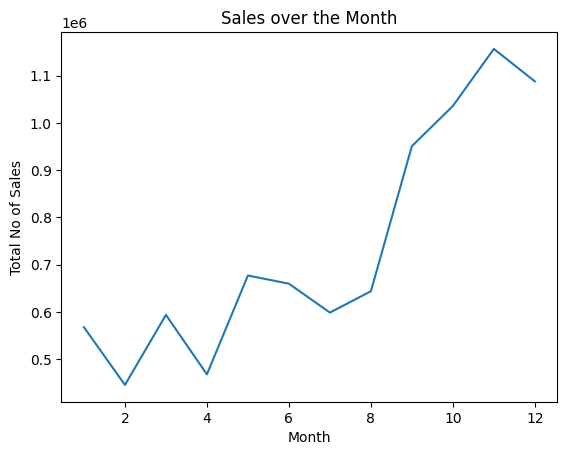

In [46]:

# Line Plot	Trends over continuous data or time
# When data changes continuously or over time

# Matplotlib:
# ● Line chart
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
monthly_sales.plot(kind='line')
plt.title("Sales over the Month")
plt.xlabel("Month")
plt.ylabel("Total No of Sales")
plt.show()

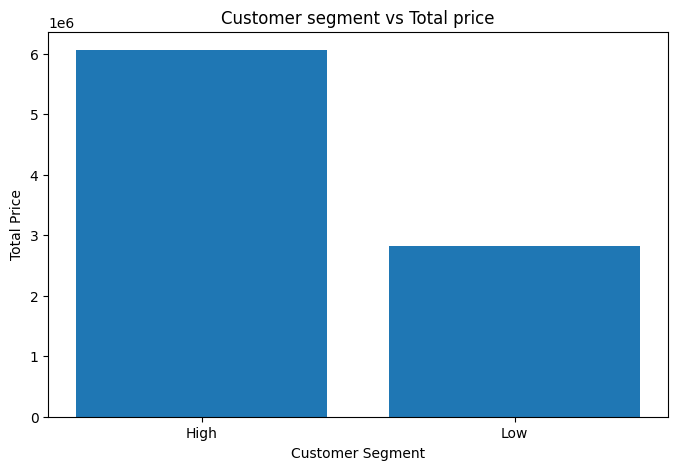

In [47]:

# ● Bar chart
#Bar Plot	Compare averages or values	When comparing numerical values across categories
bar_category=df.groupby('CustomerSegment')['TotalPrice'].sum()
plt.figure(figsize=(8,5))
plt.bar(x= bar_category.index, height = bar_category.values)
plt.title("Customer segment vs Total price")
plt.xlabel("Customer Segment")
plt.ylabel("Total Price")
plt.show()

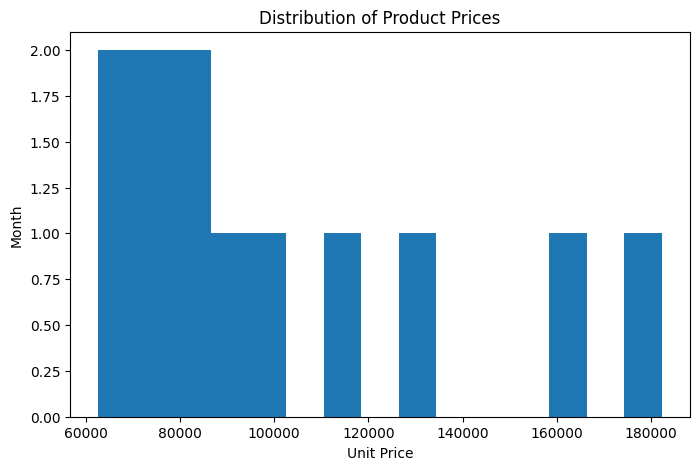

In [48]:
# ● Histogram
# Data distribution
# To see frequency distribution of one numerical variable
plt.figure(figsize=(8,5))
UnitPrice_over_month=df.groupby('Month')['UnitPrice'].sum()
plt.hist(UnitPrice_over_month, bins=15)# distribution of unit price
plt.xlabel('Unit Price')
plt.ylabel('Month')
plt.title('Distribution of Product Prices')
plt.show()

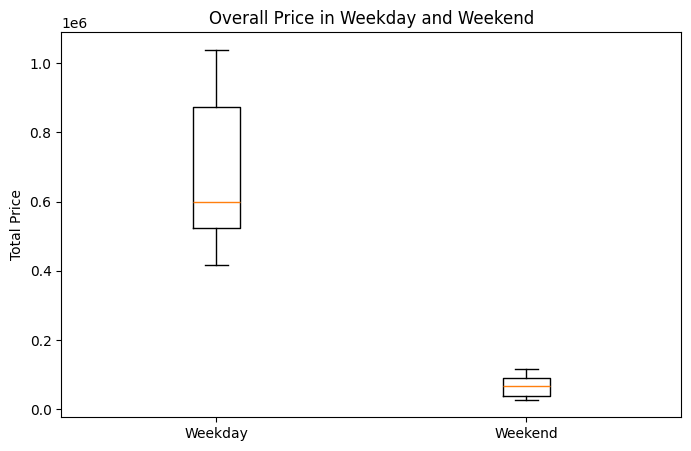

In [49]:

#box plot
#To identify median, spread, and outliers
plt.figure(figsize=(8,5))
plt.boxplot([pivot_best['Weekday'], pivot_best['Weekend']])
plt.xticks([1, 2], ['Weekday', 'Weekend'])
plt.ylabel('Total Price')
plt.title('Overall Price in Weekday and Weekend')
plt.show()

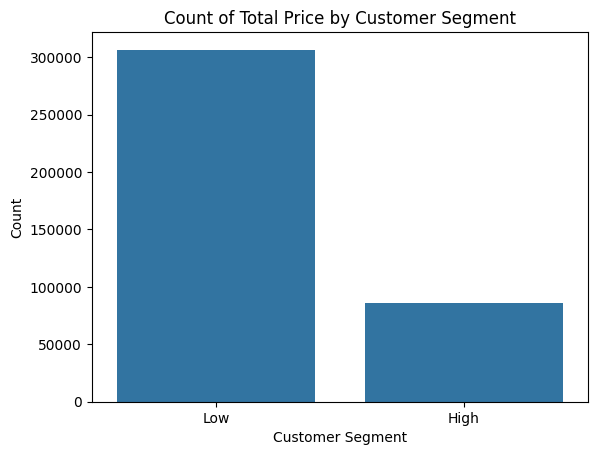

In [50]:
#Countplot
#When you want frequency/count of categorical data
import seaborn as sns
sns.countplot(x='CustomerSegment', data=df)
plt.title('Count of Total Price by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.show()


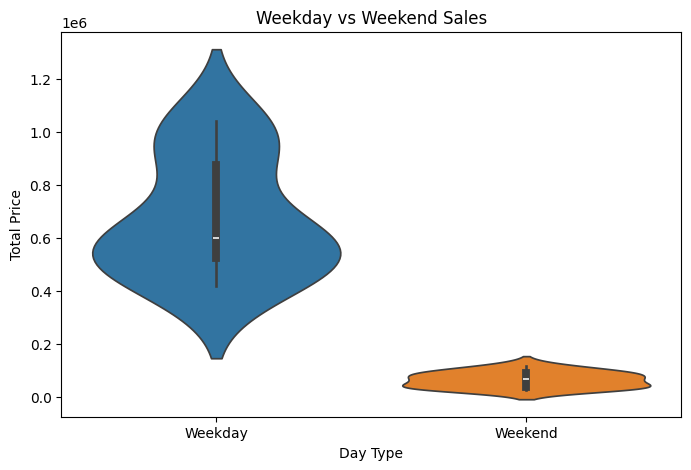

In [51]:
# # ● Violin plot
# When comparing distributions between groups
import seaborn as sns
plt.figure(figsize=(8,5))
sns.violinplot(data=pivot_best)
plt.xlabel('Day Type')
plt.ylabel('Total Price')
plt.title('Weekday vs Weekend Sales')
plt.show()

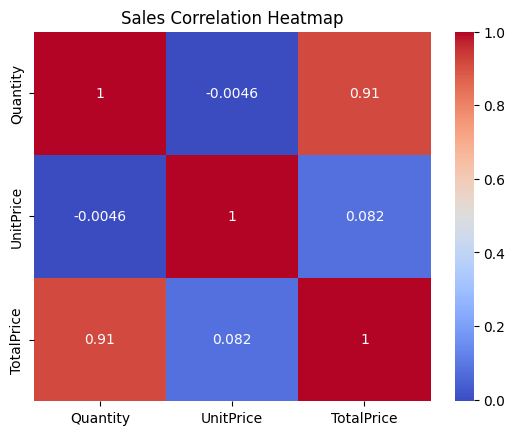

In [52]:
# Heatmap
# To identify relationships between numerical variables
corr = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Sales Correlation Heatmap')
plt.show()

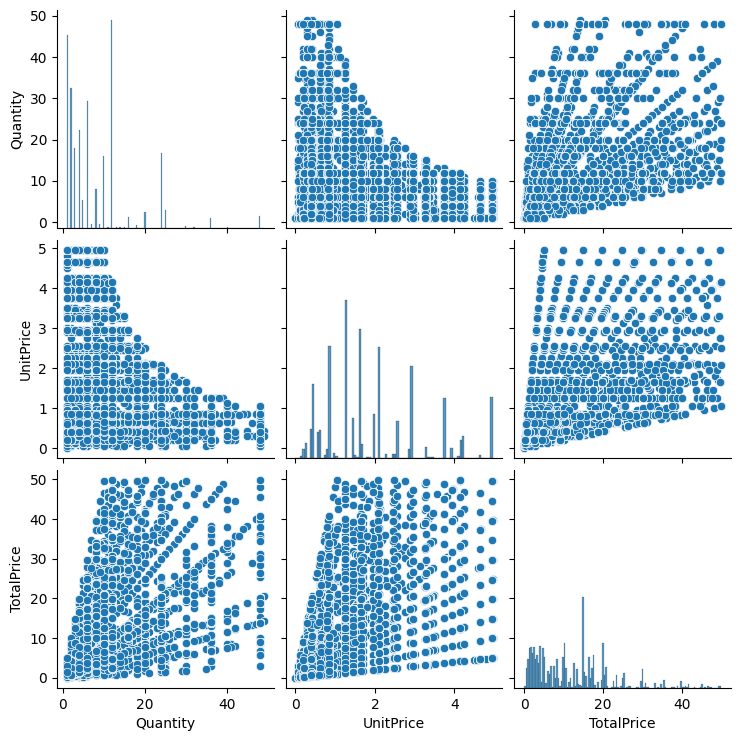

In [53]:
# Pair plot
# For quick overall EDA (Exploratory Data Analysis)
filtered_df = df[
    (df['Quantity'] < 50) &
    (df['UnitPrice'] < 5) &
    (df['TotalPrice'] < 50)
]

sns.pairplot(filtered_df[['Quantity', 'UnitPrice', 'TotalPrice']])
plt.show()

In [54]:
# Task 8 – Business Insights
# ● Identify:
# 1. Top country
top_country = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
print(top_country.head(1))

Country
United Kingdom    7285024.644
Name: TotalPrice, dtype: float64


In [55]:
# 2. Best Sales Month
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month
best_month = df.groupby('Month')['TotalPrice'].sum().sort_values(ascending=False)

print((best_month).head(1))

Month
11    1156205.61
Name: TotalPrice, dtype: float64


In [56]:
# 3. Peak Sales Time
df['Hour'] = df['InvoiceDate'].dt.hour
peak_time = df.groupby('Hour')['TotalPrice'].sum().sort_values(ascending=False)
print(peak_time.head(1))


Hour
12    1373695.39
Name: TotalPrice, dtype: float64


In [63]:
# 4.Analyze:
# ○ Customer behavior
customer_behavior = df.groupby('CustomerID')['ï»¿InvoiceNo'].count().sort_values(ascending=False)
print(customer_behavior.head())

CustomerID
17841.0    7676
14911.0    5670
14096.0    5111
12748.0    4412
14606.0    2677
Name: ï»¿InvoiceNo, dtype: int64


In [64]:
# 5. High-Value Customers
high_value = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)
print(high_value.head(10))


CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64


In [65]:
# 6. Top Products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
print(top_products.head(10))

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [66]:
df.to_csv('cleaned_data.csv', index=False)